**Author:** Steve Landry Ndjock 

**Version:** 1.0

**Python version:**  3.x

In [1]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression
from sklearn.experimental import enable_iterative_imputer

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)


In [10]:
from collections import Counter
from collections import defaultdict

# Data Preparation

In [2]:
df_original = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
df = df_original.copy()

In [3]:
def encoder_labels_categoriques(df):
    """
    Prend un DataFrame en entrée, convertit les variables catégoriques 
    en nombres entiers (0, 1, 2, 3...) dans la même colonne, et retourne le DataFrame.
    """
    # 1. Copier le dataset pour éviter de modifier l'original
    df_encode = df.copy()
    
    # 2. Identifier les colonnes contenant du texte
    colonnes_categoriques = df_encode.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not colonnes_categoriques:
        print("Aucune colonne catégorique trouvée.")
        return df_encode
    
    # 3. Remplacer le texte par des codes numériques
    for colonne in colonnes_categoriques:
        # Convertit en type catégorie, puis récupère les codes numériques
        df_encode[colonne] = df_encode[colonne].astype('category').cat.codes
        
    return df_encode

In [4]:
df = encoder_labels_categoriques(df)

In [5]:
df.drop(columns=["PCIAT-PCIAT_Total", "sii"], inplace=True)

In [6]:
X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

In [7]:
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,0,5.0,0.0,3,51.00,0,46.000,50.8,26.0,73.9,...,0,50.55,71.8,0,3,16.877316,6.5,12.3225,2.006,448.0
1,2,9.0,0.0,1,62.55,0,48.000,46.0,22.0,75.0,...,0,46.00,64.0,2,0,14.035590,11.0,20.6250,2.010,334.0
2,2,10.0,1.0,0,71.00,0,56.500,75.6,25.4,65.0,...,0,38.00,54.0,2,2,16.648696,10.0,12.4500,2.009,453.0
3,3,9.0,0.0,0,71.00,2,56.000,81.6,26.0,60.0,...,2,31.00,45.0,3,0,18.292347,7.0,20.6250,2.010,577.0
4,1,18.0,1.0,2,65.00,1,55.003,77.0,26.0,68.0,...,0,41.60,61.4,1,1,17.894545,9.1,21.5525,1.040,460.0


In [8]:
X.shape

(8460, 83)

In [9]:
np.unique(y, return_counts=True)

(array([0, 1, 2, 3], dtype=int64),
 array([6484, 1644,  326,    6], dtype=int64))

In [11]:
# I merge class 2 and 3 into a single class (class 2)
y = np.where(y == 3, 2, y)

In [12]:
ctr = Counter(y)
ctr

Counter({0: 6484, 1: 1644, 2: 332})

# Data Partitioning

In [13]:
from sklearn.model_selection import train_test_split, cross_val_score 

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=100, stratify=y)

In [15]:
X_train.shape

(5922, 83)

# Classification

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score
from scikitplot.metrics import plot_roc
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay 

In [17]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.8869188337273444
F1-score [0.93997446 0.71052632 0.69364162]
              precision    recall  f1-score   support

           0      0.934     0.946     0.940      1945
           1      0.709     0.712     0.711       493
           2      0.822     0.600     0.694       100

    accuracy                          0.887      2538
   macro avg      0.822     0.753     0.781      2538
weighted avg      0.886     0.887     0.886      2538



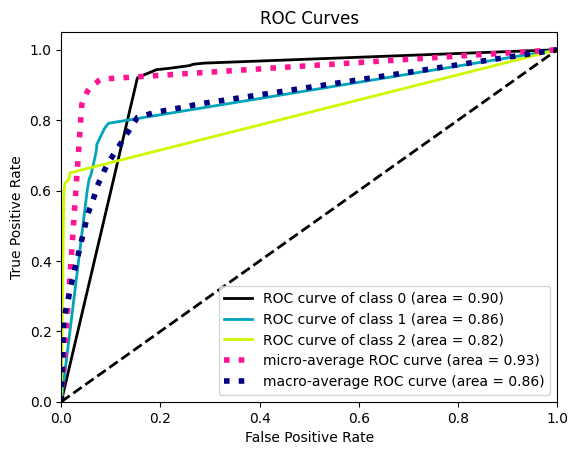

In [18]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

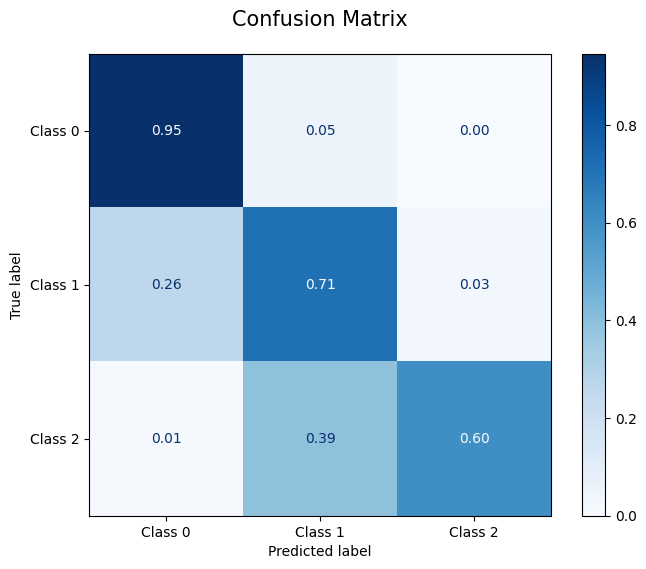

In [19]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

# Feature Selection

## Variance Threshold

In [20]:
np.histogram(np.var(X_train, axis=0)[np.var(X_train, axis=0) < 3.14e04])

(array([79,  1,  0,  0,  0,  0,  0,  0,  0,  1], dtype=int64),
 array([7.43356408e-02, 6.71341509e+02, 1.34260868e+03, 2.01387585e+03,
        2.68514303e+03, 3.35641020e+03, 4.02767737e+03, 4.69894455e+03,
        5.37021172e+03, 6.04147889e+03, 6.71274607e+03]))

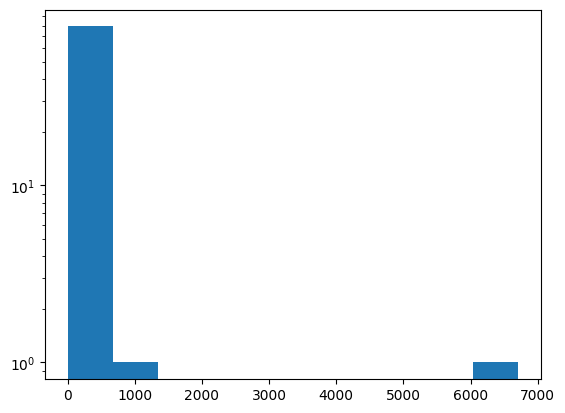

In [21]:
plt.hist(np.var(X_train, axis=0)[np.var(X_train, axis=0) < 3.14e04])
plt.yscale('log')
plt.show()

In [22]:
from sklearn.feature_selection import VarianceThreshold

In [18]:
(.8 * (1 - .8))

0.15999999999999998

In [23]:
sel = VarianceThreshold(threshold=(.8 * (1 - .8)))
X_train_sel = sel.fit_transform(X_train)

X_train_sel.shape

(5922, 77)

In [24]:
X_train.shape

(5922, 83)

In [25]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.8873128447596532
F1-score [0.93958013 0.71543086 0.69767442]
              precision    recall  f1-score   support

           0      0.936     0.943     0.940      1945
           1      0.707     0.724     0.715       493
           2      0.833     0.600     0.698       100

    accuracy                          0.887      2538
   macro avg      0.825     0.756     0.784      2538
weighted avg      0.887     0.887     0.887      2538



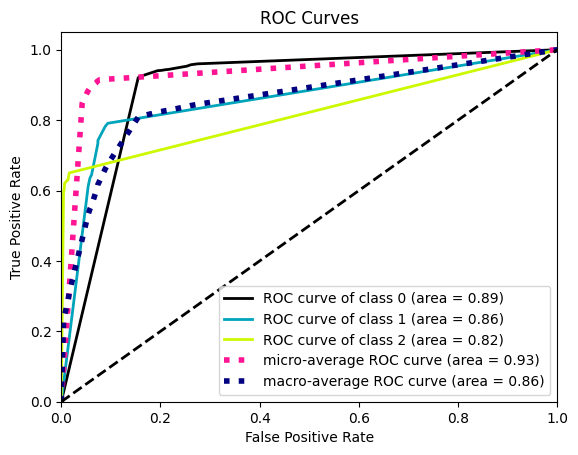

In [26]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

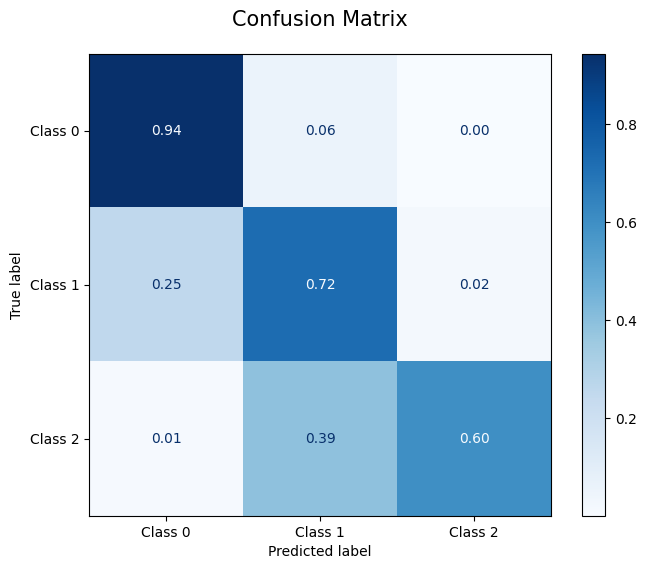

In [27]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Univariate Feature Selection

In [28]:
from sklearn.feature_selection import SelectKBest

In [29]:
sel = SelectKBest(k=40, score_func=f_classif)
X_train_sel = sel.fit_transform(X_train, y_train)

X_train_sel.shape

(5922, 40)

In [30]:
sel.scores_

array([9.34908635e-02, 3.63857800e+01, 1.49048548e+01, 1.02430698e+00,
       2.01795929e+01, 7.80513164e+00, 5.23151816e+01, 4.16117638e+01,
       2.03053775e+01, 1.59493295e+01, 2.25972712e+00, 3.58030939e+01,
       3.27738555e+00, 1.03490574e+00, 6.71823938e-01, 8.98419973e-01,
       2.81323063e+00, 5.79313810e+01, 5.34882943e+00, 7.12515758e+00,
       9.62120398e+00, 5.46168955e+00, 7.10874053e+00, 4.63047805e+01,
       1.50214456e+01, 3.25238580e-01, 4.22479614e+00, 3.59868823e+00,
       2.36816902e+00, 1.02372327e+01, 6.34916681e+00, 3.81480013e+00,
       8.62476088e-01, 9.01523467e+00, 1.98672054e+01, 2.75345840e+01,
       4.46458722e+01, 2.82635669e+01, 2.84450163e+01, 2.76704984e+01,
       1.33605703e+01, 2.29651040e+01, 1.35534909e+01, 4.59365479e+01,
       2.23287429e+01, 3.48863463e+01, 3.15369214e+01, 4.31421555e+01,
       1.69353748e+01, 1.24909494e+01, 4.62649111e+00, 2.58858758e+00,
       6.65373259e-01, 1.41769326e+03, 1.56793382e+03, 1.88619946e+03,
      

In [31]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.8975571315996848
F1-score [0.94548247 0.73864783 0.73033708]
              precision    recall  f1-score   support

           0      0.941     0.950     0.945      1945
           1      0.735     0.742     0.739       493
           2      0.833     0.650     0.730       100

    accuracy                          0.898      2538
   macro avg      0.837     0.781     0.805      2538
weighted avg      0.897     0.898     0.897      2538



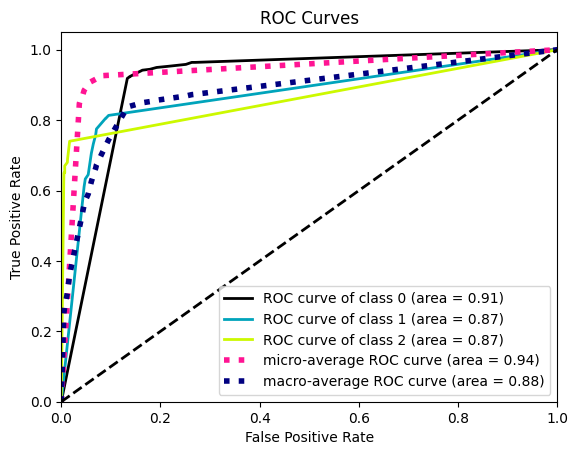

In [32]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

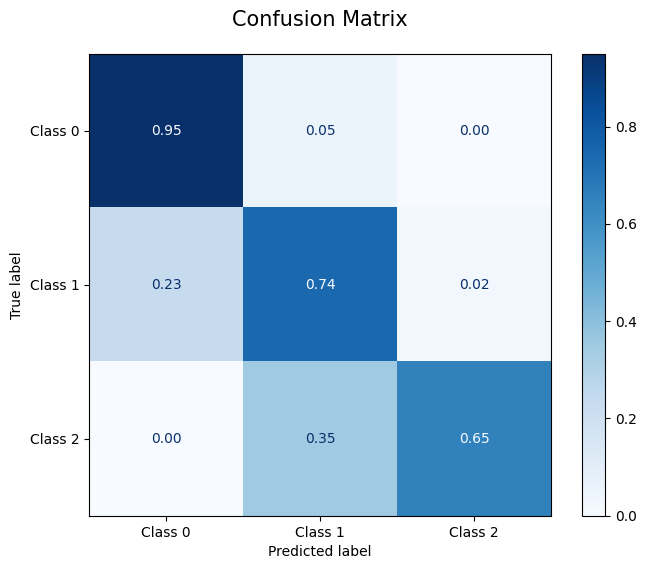

In [33]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Recursive Feature Elimination (RFE)

In [34]:
from sklearn.feature_selection import RFE

In [35]:
sel = RFE(DecisionTreeClassifier(), n_features_to_select=4)
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 4)

In [36]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.8455476753349094
F1-score [0.9183725  0.59275053 0.56353591]
              precision    recall  f1-score   support

           0      0.903     0.934     0.918      1945
           1      0.625     0.564     0.593       493
           2      0.630     0.510     0.564       100

    accuracy                          0.846      2538
   macro avg      0.719     0.669     0.692      2538
weighted avg      0.838     0.846     0.841      2538



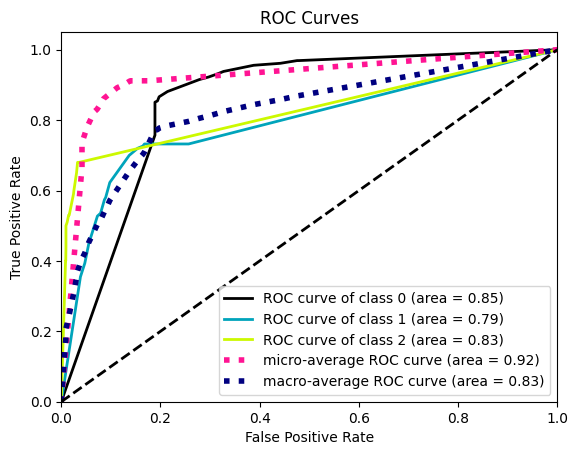

In [37]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

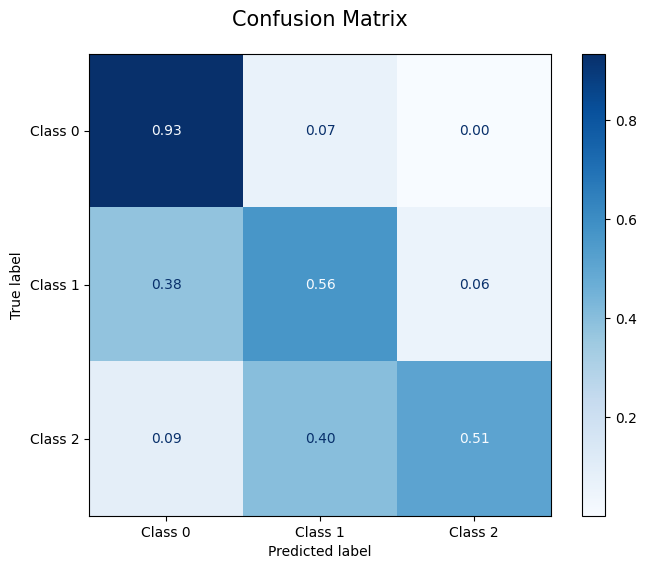

In [38]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Select Form Model
Meta-transformer for selecting features based on importance weights.

In [39]:
from sklearn.feature_selection import SelectFromModel

In [40]:
sel = SelectFromModel(DecisionTreeClassifier())
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 12)

In [41]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.9066193853427896
F1-score [0.95201633 0.75619835 0.73684211]
              precision    recall  f1-score   support

           0      0.945     0.959     0.952      1945
           1      0.771     0.742     0.756       493
           2      0.778     0.700     0.737       100

    accuracy                          0.907      2538
   macro avg      0.831     0.800     0.815      2538
weighted avg      0.905     0.907     0.906      2538



In [42]:
# 1. Get the boolean mask (True for kept features, False for removed)
mask = sel.get_support()

# 2. Apply this mask to your ORIGINAL column names
# Replace 'df' with the name of your original DataFrame
original_feature_names = df.columns
real_feature_names = original_feature_names[mask]

# 3. Create the cleaned-up importance table
feature_importance_df = pd.DataFrame({
    'Feature': real_feature_names,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

            Feature  Importance
4    PCIAT-PCIAT_05    0.402618
8    PCIAT-PCIAT_15    0.119791
9    PCIAT-PCIAT_18    0.095237
0   Physical-Height    0.063574
2    PCIAT-PCIAT_03    0.063088
10   PCIAT-PCIAT_19    0.052187
6    PCIAT-PCIAT_11    0.040730
5    PCIAT-PCIAT_07    0.037885
7    PCIAT-PCIAT_14    0.037341
1    PCIAT-PCIAT_02    0.033070
11   PCIAT-PCIAT_20    0.028001
3    PCIAT-PCIAT_04    0.026478


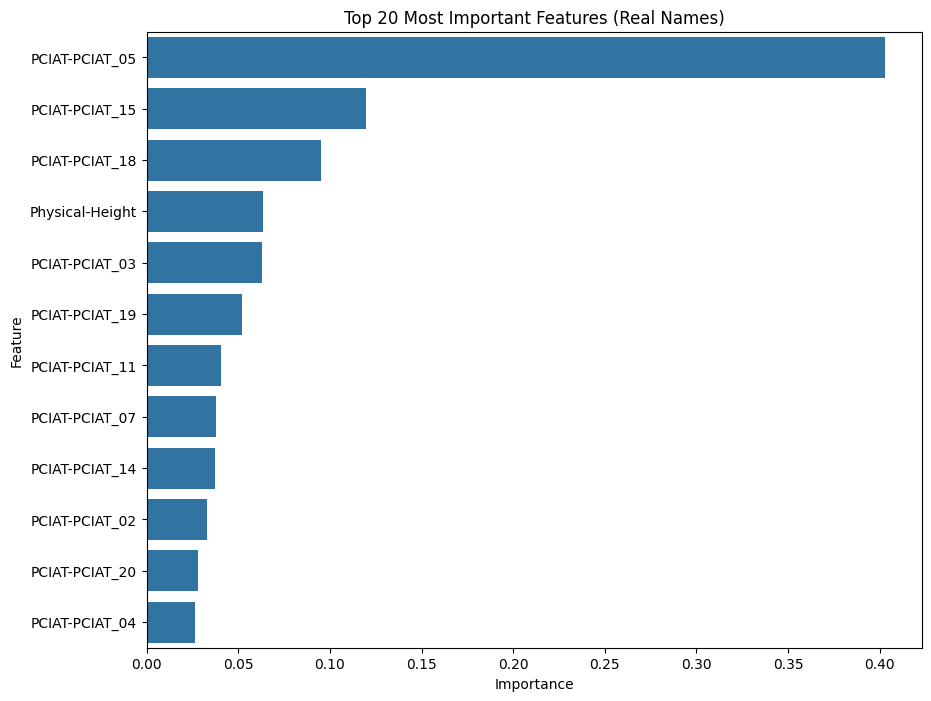

In [43]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Most Important Features (Real Names)')
plt.show()

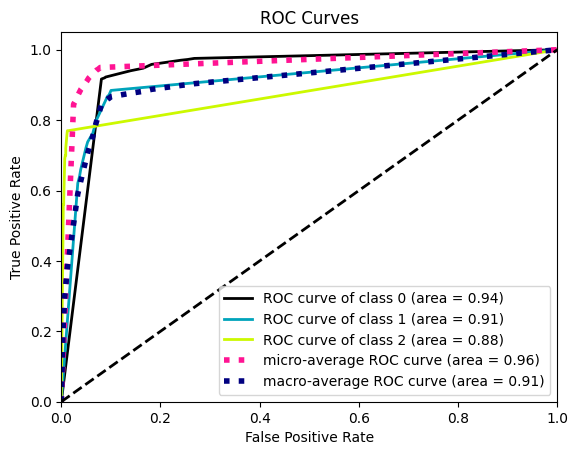

In [44]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

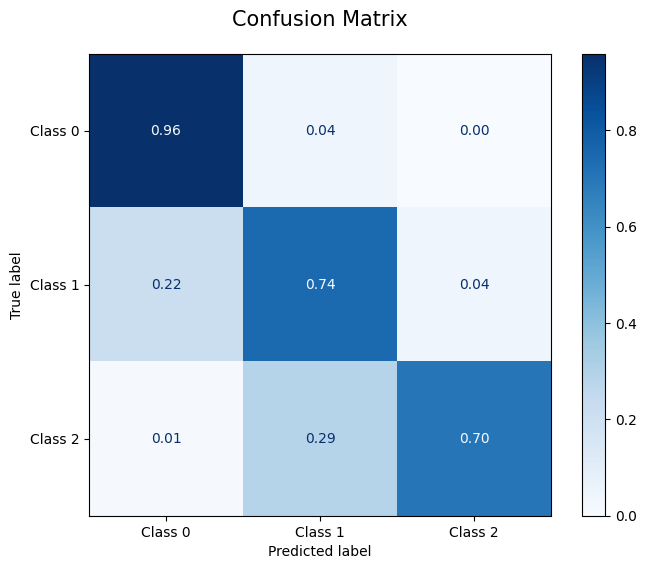

In [46]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

### Gradient Boosting

In [47]:
import xgboost as xgb

In [48]:
sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 19)

In [49]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.9101654846335697
F1-score [0.95389344 0.77016129 0.73333333]
              precision    recall  f1-score   support

           0      0.950     0.957     0.954      1945
           1      0.766     0.775     0.770       493
           2      0.825     0.660     0.733       100

    accuracy                          0.910      2538
   macro avg      0.847     0.797     0.819      2538
weighted avg      0.910     0.910     0.910      2538



In [50]:
# Access the fitted XGBoost model from the selector
trained_xgb = sel.estimator_

# Get importance (Gain represents the improvement in accuracy brought by a feature)
importance = trained_xgb.get_booster().get_score(importance_type='gain')

# Sort and print for better readability
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
print(sorted_importance)

[('f70', 15.399357795715332), ('f57', 11.275545120239258), ('f67', 9.960391998291016), ('f69', 6.937339782714844), ('f55', 4.76829719543457), ('f54', 4.083531856536865), ('f48', 3.9536378383636475), ('f71', 2.781217575073242), ('f60', 2.4157700538635254), ('f65', 2.275524616241455), ('f61', 1.8600624799728394), ('f66', 1.828633189201355), ('f53', 1.7885010242462158), ('f62', 1.6462820768356323), ('f58', 1.5644420385360718), ('f72', 1.530068278312683), ('f63', 1.4631367921829224), ('f59', 1.4387903213500977), ('f64', 1.412253975868225), ('f56', 1.092892050743103), ('f68', 0.9126570224761963), ('f7', 0.8272418975830078), ('f24', 0.7457017302513123), ('f6', 0.7410420179367065), ('f17', 0.6912279725074768), ('f19', 0.6073898077011108), ('f73', 0.5498616695404053), ('f44', 0.5437677502632141), ('f27', 0.5381879210472107), ('f45', 0.5325940251350403), ('f14', 0.5264789462089539), ('f34', 0.4835399091243744), ('f36', 0.48051774501800537), ('f37', 0.469743549823761), ('f1', 0.46632564067840576

In [51]:
original_cols = df.columns 

# Apply the mask to get only the features the selector kept
selected_names = original_cols[sel.get_support()]

# Create the table
dt_importance = pd.DataFrame({
    'Feature': selected_names,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- Decision Tree Importance ---")
print(dt_importance.head(20))

--- Decision Tree Importance ---
           Feature  Importance
4   PCIAT-PCIAT_05    0.395643
14  PCIAT-PCIAT_15    0.117711
16  PCIAT-PCIAT_18    0.085269
3   PCIAT-PCIAT_03    0.057586
17  PCIAT-PCIAT_19    0.045296
6   PCIAT-PCIAT_07    0.038538
10  PCIAT-PCIAT_11    0.033180
5   PCIAT-PCIAT_06    0.027676
12  PCIAT-PCIAT_13    0.024618
8   PCIAT-PCIAT_09    0.023745
18  PCIAT-PCIAT_20    0.022119
2   PCIAT-PCIAT_02    0.022111
13  PCIAT-PCIAT_14    0.018467
11  PCIAT-PCIAT_12    0.017770
9   PCIAT-PCIAT_10    0.017756
15  PCIAT-PCIAT_17    0.017747
1   PCIAT-PCIAT_01    0.015516
7   PCIAT-PCIAT_08    0.014836
0     PAQ_A-Season    0.004417


In [52]:
importance_dict = trained_xgb.get_booster().get_score(importance_type='gain')

# 2. Map 'f#' to the column name at that index
# We use the original_cols list we defined above
real_names_dict = {}
for f_code, score in importance_dict.items():
    index = int(f_code.replace('f', ''))
    name = original_cols[index]
    real_names_dict[name] = score

# 3. Create the sorted table
xgb_importance = pd.DataFrame({
    'Feature': list(real_names_dict.keys()),
    'Gain': list(real_names_dict.values())
}).sort_values(by='Gain', ascending=False)

print("\n--- XGBoost Importance (Gain) ---")
print(xgb_importance.head(10))


--- XGBoost Importance (Gain) ---
           Feature       Gain
70  PCIAT-PCIAT_18  15.399358
57  PCIAT-PCIAT_05  11.275545
67  PCIAT-PCIAT_15   9.960392
69  PCIAT-PCIAT_17   6.937340
55  PCIAT-PCIAT_03   4.768297
54  PCIAT-PCIAT_02   4.083532
48    PAQ_A-Season   3.953638
71  PCIAT-PCIAT_19   2.781218
60  PCIAT-PCIAT_08   2.415770
65  PCIAT-PCIAT_13   2.275525


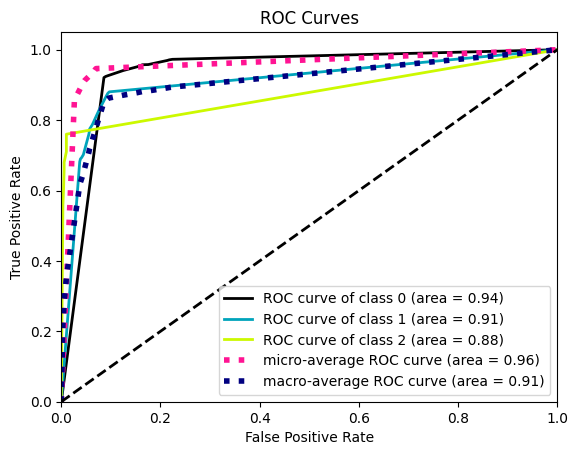

In [53]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

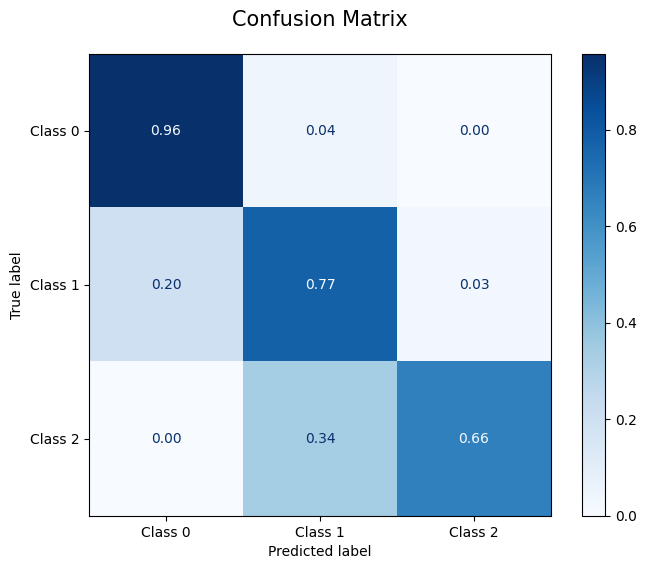

In [54]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

# Feature Projection

## Principal Component Analysis

In [55]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler   

In [56]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [58]:
X_train_pca.shape

(5922, 2)

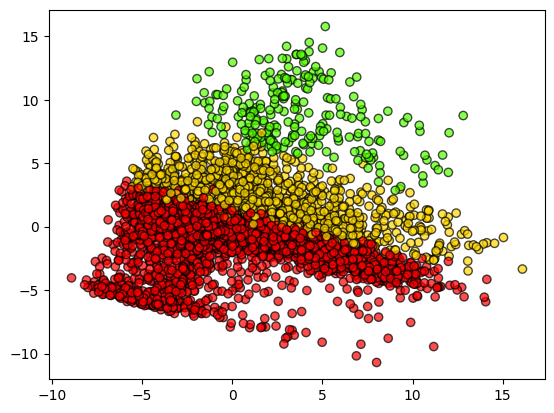

In [59]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, 
            cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [60]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_pca, y_train)

y_pred = clf.predict(X_test_pca)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9468085106382979
F1-score [0.96994606 0.86349848 0.90721649]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1945
           1       0.86      0.87      0.86       493
           2       0.94      0.88      0.91       100

    accuracy                           0.95      2538
   macro avg       0.92      0.91      0.91      2538
weighted avg       0.95      0.95      0.95      2538



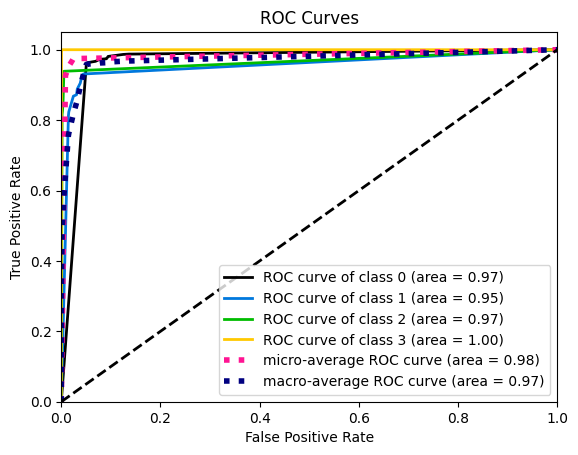

In [118]:
y_score = clf.predict_proba(X_test_pca)
plot_roc(y_test, y_score)
plt.show()

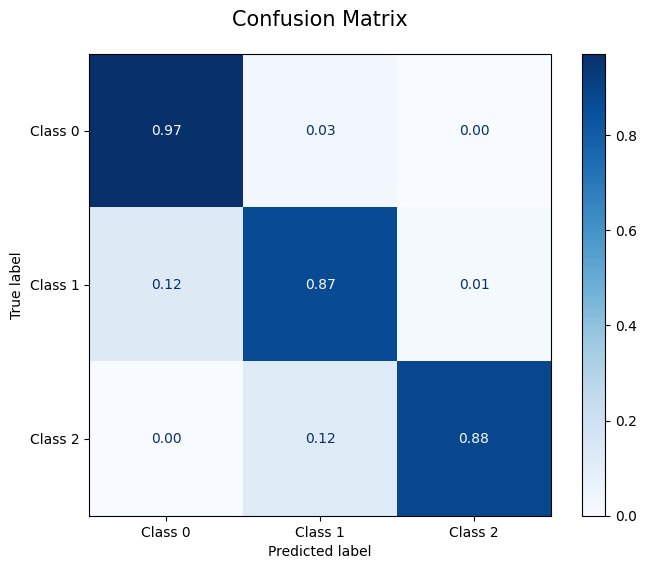

In [61]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

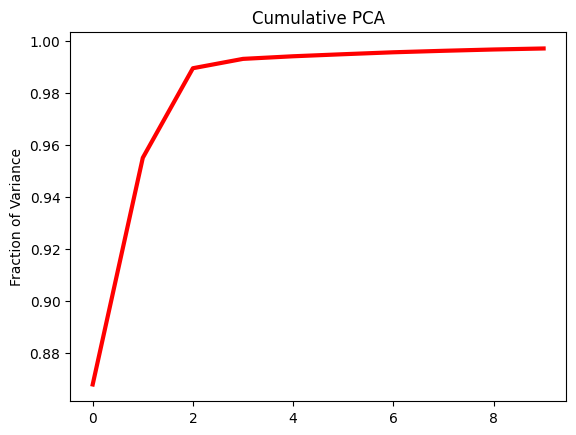

In [62]:
plt.plot(np.cumsum(PCA(n_components=10).fit(X).explained_variance_ratio_), lw=3, color='r', ms=2)
plt.title("Cumulative PCA")
plt.ylabel("Fraction of Variance")
plt.show()

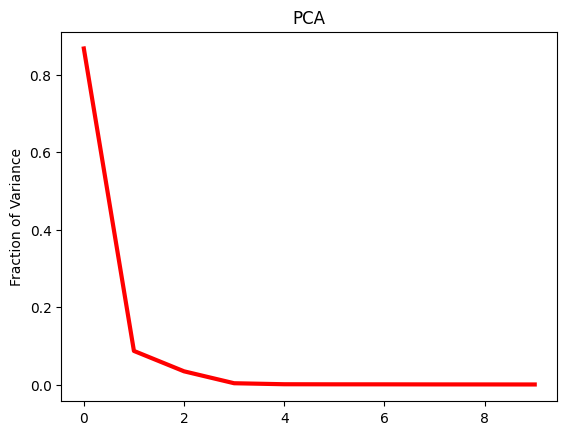

In [63]:
plt.plot(PCA(n_components=10).fit(X).explained_variance_ratio_, lw=3, color='r', ms=2)
plt.title("PCA")
plt.ylabel("Fraction of Variance")
plt.show()

# Random Subspace Projection

In [64]:
from sklearn import random_projection

In [65]:
rsp = random_projection.GaussianRandomProjection(n_components=2, random_state=None)
X_train_rsp = rsp.fit_transform(X_train_scaled)
X_test_rsp = rsp.transform(X_test_scaled)
X_train_rsp.shape

(5922, 2)

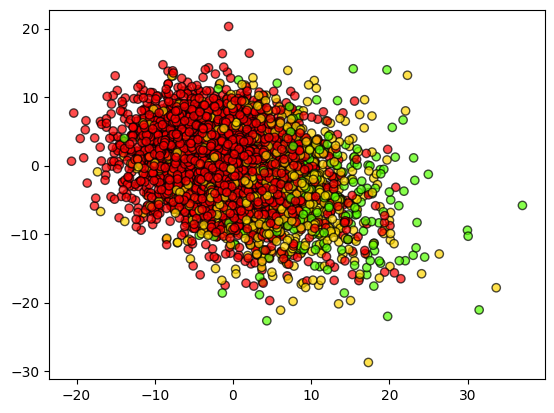

In [66]:
plt.scatter(X_train_rsp[:, 0], X_train_rsp[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [67]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_rsp, y_train)

y_pred = clf.predict(X_test_rsp)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.7198581560283688
F1-score [0.83748754 0.27716186 0.27160494]
              precision    recall  f1-score   support

           0       0.81      0.86      0.84      1945
           1       0.31      0.25      0.28       493
           2       0.35      0.22      0.27       100

    accuracy                           0.72      2538
   macro avg       0.49      0.45      0.46      2538
weighted avg       0.70      0.72      0.71      2538



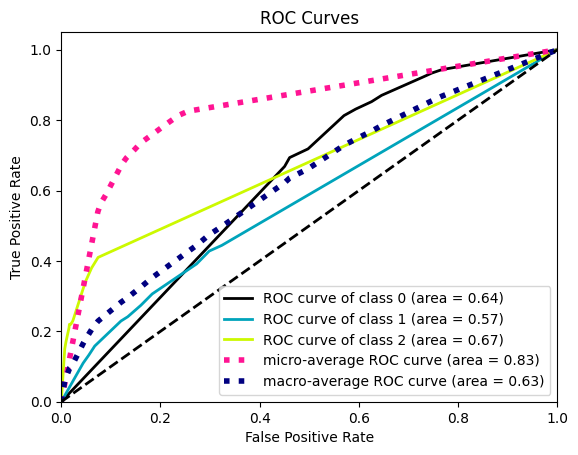

In [68]:
y_score = clf.predict_proba(X_test_rsp)
plot_roc(y_test, y_score)
plt.show()

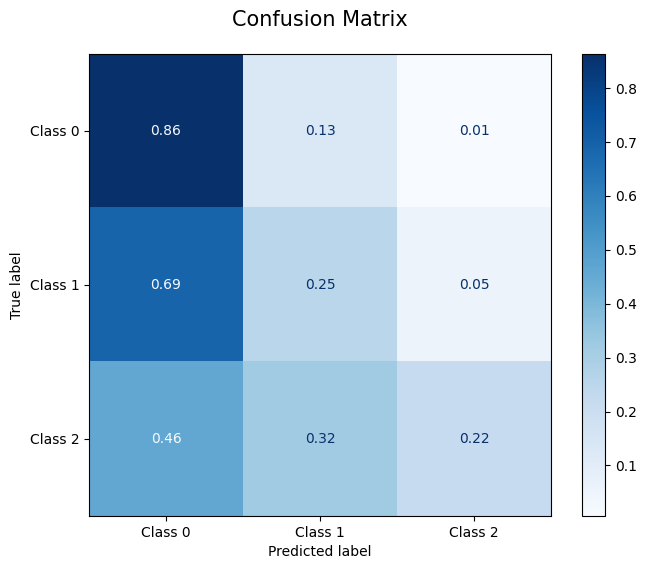

In [69]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Multi Dimensional Scaling

In [70]:
from sklearn.manifold import MDS

In [81]:
# Specifichiamo n_init e init per evitare i FutureWarning
mds = MDS(
    n_components=2, 
    n_init=4,           # Valore attuale di default (cambierà a 1 in futuro)
    init='random',      # Valore attuale di default (cambierà a 'classical_mds')
    normalized_stress='auto',
    random_state=42     # Sempre consigliato per rendere i risultati riproducibili
)

X_train_mds = mds.fit_transform(X_train_scaled)
print(X_train_mds.shape)

(5922, 2)


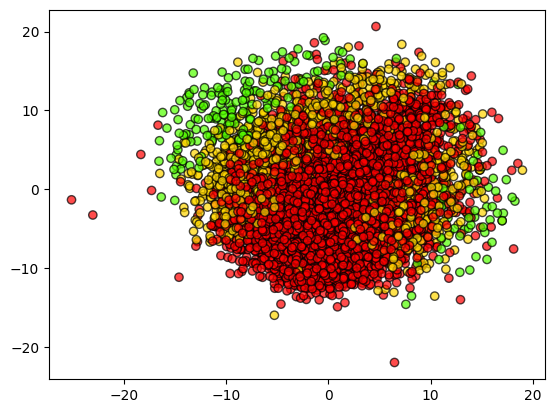

In [82]:
plt.scatter(X_train_mds[:, 0], X_train_mds[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [83]:
#X_test_mds = mds.transform(X_test) # no transform

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_mds, y_train)

y_pred = clf.predict(X_train_mds)

print('Accuracy %s' % accuracy_score(y_train, y_pred))
print('F1-score %s' % f1_score(y_train, y_pred, average=None))
print(classification_report(y_train, y_pred))

Accuracy 0.92806484295846
F1-score [0.95826961 0.82697427 0.81651376]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      4539
           1       0.84      0.81      0.83      1151
           2       0.87      0.77      0.82       232

    accuracy                           0.93      5922
   macro avg       0.89      0.85      0.87      5922
weighted avg       0.93      0.93      0.93      5922



## IsoMap

In [71]:
from sklearn.manifold import Isomap

In [72]:
iso = Isomap(n_components=2, n_neighbors=8) # n_neighbors=5 is the default, but it is important to specify it here to avoid a warning about future changes in the default value
X_train_iso = iso.fit_transform(X_train_scaled)
X_test_iso = iso.transform(X_test_scaled)
X_train_iso.shape

(5922, 2)

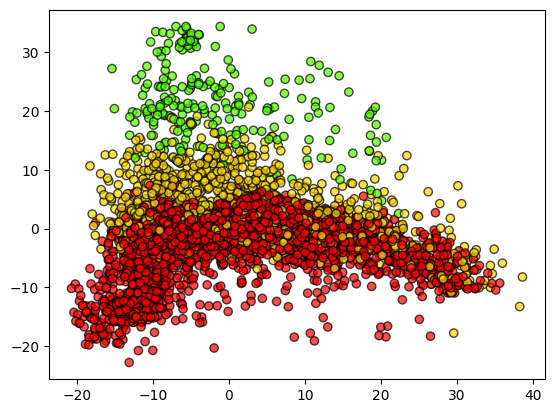

In [73]:
plt.scatter(X_train_iso[:, 0], X_train_iso[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [74]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_iso, y_train)

y_pred = clf.predict(X_test_iso)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.8029944838455477
F1-score [0.88462509 0.45733042 0.76616915]
              precision    recall  f1-score   support

           0       0.87      0.90      0.88      1945
           1       0.50      0.42      0.46       493
           2       0.76      0.77      0.77       100

    accuracy                           0.80      2538
   macro avg       0.71      0.70      0.70      2538
weighted avg       0.79      0.80      0.80      2538



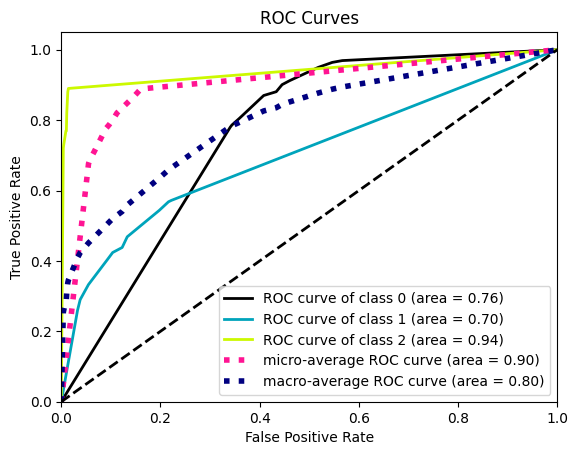

In [75]:
y_score = clf.predict_proba(X_test_iso)
plot_roc(y_test, y_score)
plt.show()

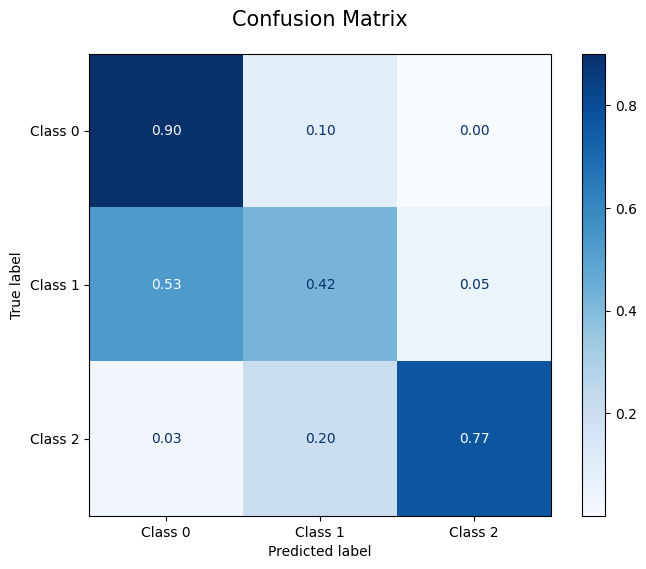

In [76]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## t-SNE

In [77]:
from sklearn.manifold import TSNE

In [78]:
tsne = TSNE(n_components=2)
X_train_tsne = tsne.fit_transform(X_train_scaled)
X_train_tsne.shape

(5922, 2)

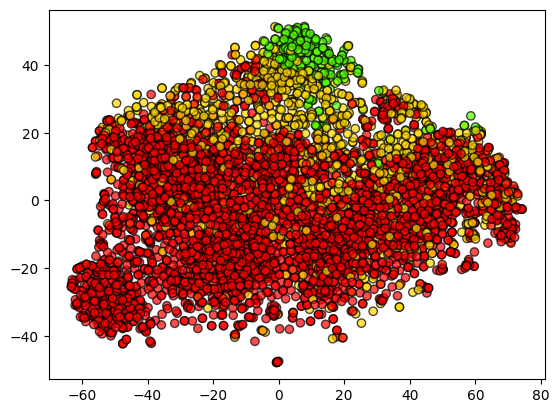

In [79]:
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [80]:
#X_test_mds = mds.transform(X_test) # no transform

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_tsne, y_train)

y_pred = clf.predict(X_train_tsne)

print('Accuracy %s' % accuracy_score(y_train, y_pred))
print('F1-score %s' % f1_score(y_train, y_pred, average=None))
print(classification_report(y_train, y_pred))

Accuracy 0.9415737926376224
F1-score [0.96511755 0.84629133 0.93709328]
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      4539
           1       0.87      0.82      0.85      1151
           2       0.94      0.93      0.94       232

    accuracy                           0.94      5922
   macro avg       0.92      0.91      0.92      5922
weighted avg       0.94      0.94      0.94      5922

